# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [12]:
df= pd.read_csv("cleaned_aviation_data.csv", low_memory= False)
df

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Airport.Code,Airport.Name,Injury.Severity,Aircraft.damage,...,Purpose.of.flight,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date,AircraftID
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,Fatal(2),Destroyed,...,PERSONAL,2.0,0.0,0.0,0.0,UNKNOWN,CRUISE,Probable Cause,NaN,STINSON 108-3
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,Fatal(4),Destroyed,...,PERSONAL,4.0,0.0,0.0,0.0,UNKNOWN,UNKNOWN,Probable Cause,19-09-1996,PIPER PA24-180
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,NaN,NaN,Fatal(3),Destroyed,...,PERSONAL,3.0,NaN,NaN,NaN,IMC,CRUISE,Probable Cause,26-02-2007,CESSNA 172M
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,Fatal(2),Destroyed,...,PERSONAL,2.0,0.0,0.0,0.0,IMC,CRUISE,Probable Cause,12-09-2000,ROCKWELL 112
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,Fatal(1),Destroyed,...,PERSONAL,1.0,2.0,NaN,0.0,VMC,APPROACH,Probable Cause,16-04-1980,CESSNA 501
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74622,20221227106491,Accident,ERA23LA093,2022-12-26,"Annapolis, MD",United States,NaN,NaN,Minor,Unknown,...,PERSONAL,0.0,1.0,0.0,0.0,NaN,NaN,NaN,29-12-2022,PIPER PA-28-151
74623,20221227106494,Accident,ERA23LA095,2022-12-26,"Hampton, NH",United States,NaN,NaN,NaN,Unknown,...,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,BELLANCA 7ECA
74624,20221227106497,Accident,WPR23LA075,2022-12-26,"Payson, AZ",United States,PAN,PAYSON,Non-Fatal,Substantial,...,PERSONAL,0.0,0.0,0.0,1.0,VMC,NaN,NaN,27-12-2022,AMERICAN CHAMPION 8GCBC
74625,20221227106498,Accident,WPR23LA076,2022-12-26,"Morgan, UT",United States,NaN,NaN,NaN,Unknown,...,PERSONAL,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,CESSNA 210N


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [13]:
df['Serious.Fatal'] = df['Total.Fatal.Injuries'] + df['Total.Serious.Injuries']
df['Total.Passengers'] = (
    df['Serious.Fatal'] +
    df['Total.Minor.Injuries'] +
    df['Total.Uninjured']
)


small_aircraft = df[df['Total.Passengers'] <= 20]
large_aircraft = df[df['Total.Passengers'] > 20]

small_aircraft

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Airport.Code,Airport.Name,Injury.Severity,Aircraft.damage,...,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date,AircraftID,Serious.Fatal,Total.Passengers
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,Fatal(2),Destroyed,...,0.0,0.0,0.0,UNKNOWN,CRUISE,Probable Cause,NaN,STINSON 108-3,2.0,2.0
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,Fatal(4),Destroyed,...,0.0,0.0,0.0,UNKNOWN,UNKNOWN,Probable Cause,19-09-1996,PIPER PA24-180,4.0,4.0
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,Fatal(2),Destroyed,...,0.0,0.0,0.0,IMC,CRUISE,Probable Cause,12-09-2000,ROCKWELL 112,2.0,2.0
6,20001218X45446,Accident,CHI81LA106,1981-08-01,"COTTON, MN",United States,NaN,NaN,Fatal(4),Destroyed,...,0.0,0.0,0.0,IMC,UNKNOWN,Probable Cause,06-11-2001,CESSNA 180,4.0,4.0
7,20020909X01562,Accident,SEA82DA022,1982-01-01,"PULLMAN, WA",United States,NaN,BLACKBURN AG STRIP,Non-Fatal,Substantial,...,0.0,0.0,2.0,VMC,TAKEOFF,Probable Cause,01-01-1982,CESSNA 140,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74622,20221227106491,Accident,ERA23LA093,2022-12-26,"Annapolis, MD",United States,NaN,NaN,Minor,Unknown,...,1.0,0.0,0.0,NaN,NaN,NaN,29-12-2022,PIPER PA-28-151,1.0,1.0
74623,20221227106494,Accident,ERA23LA095,2022-12-26,"Hampton, NH",United States,NaN,NaN,NaN,Unknown,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,BELLANCA 7ECA,0.0,0.0
74624,20221227106497,Accident,WPR23LA075,2022-12-26,"Payson, AZ",United States,PAN,PAYSON,Non-Fatal,Substantial,...,0.0,0.0,1.0,VMC,NaN,NaN,27-12-2022,AMERICAN CHAMPION 8GCBC,0.0,1.0
74625,20221227106498,Accident,WPR23LA076,2022-12-26,"Morgan, UT",United States,NaN,NaN,NaN,Unknown,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,CESSNA 210N,0.0,0.0


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [14]:
#Small Aircraft

small_make = small_aircraft.groupby('Make').agg({'Serious.Fatal' : 'sum',
    'Total.Passengers' : 'sum'})
small_make['Injury Rate'] = small_make['Serious.Fatal']/small_make['Total.Passengers']

#Large Aircraft
big_make = large_aircraft.groupby('Make').agg({'Serious.Fatal' : 'sum',
    'Total.Passengers' : 'sum'})

big_make['Injury Rate'] = big_make['Serious.Fatal']/big_make['Total.Passengers']
big_make

,Serious.Fatal,Total.Passengers,Injury Rate
Make,,,
AERO COMMANDER,0.0,90.0,0.000000
AEROSPATIALE,120.0,1902.0,0.063091
AIRBUS,1830.0,34149.0,0.053589
BEECH,74.0,602.0,0.122924
BELL,25.0,25.0,1.000000
BOEING,6641.0,175576.0,0.037824
BOMBARDIER,112.0,4165.0,0.026891
BRITISH AEROSPACE,45.0,1490.0,0.030201
CANADAIR,8.0,172.0,0.046512


**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [19]:
small_make['Injury Rate'].sort_values().head(10)

Make
BOMBARDIER         0.095890
SWEARINGEN         0.108989
WACO               0.110204
FOKKER             0.125000
HELIO              0.140969
BOEING             0.142684
BOEING STEARMAN    0.147541
LET                0.147929
FAIRCHILD          0.151235
MAULE              0.164196
Name: Injury Rate, dtype: float64

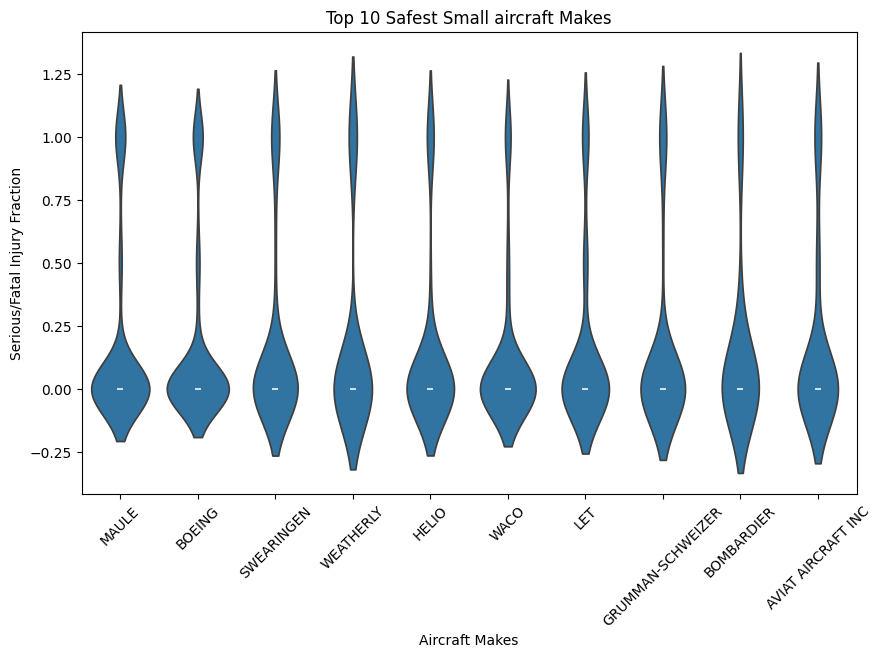

In [25]:
#Lets remove invalid rows first

df = df.dropna(subset= ['Total.Passengers','Serious.Fatal'])
df = df[df['Total.Passengers'] > 0] # Passengers must be greater than 0 to be considered valid

df['Injury_fraction'] = df['Serious.Fatal']/df['Total.Passengers']

# Let's filter the small aircrafts
small = df[df['Total.Passengers'] <= 20]

#Mean injury Fraction per make
mean_per_make = small.groupby('Make')['Injury_fraction'].mean()


#Top 10 Safest Aircraft Makes
top_10_makes = mean_per_make.sort_values().head(10).index

small_top10 = small[small['Make'].isin(top_10_makes)]

plt.figure(figsize=(10,6))
sns.violinplot(data= small_top10, x= 'Make', y= 'Injury_fraction')
plt.title("Top 10 Safest Small aircraft Makes")
plt.xlabel("Aircraft Makes")
plt.ylabel("Serious/Fatal Injury Fraction")
plt.xticks(rotation = 45)
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

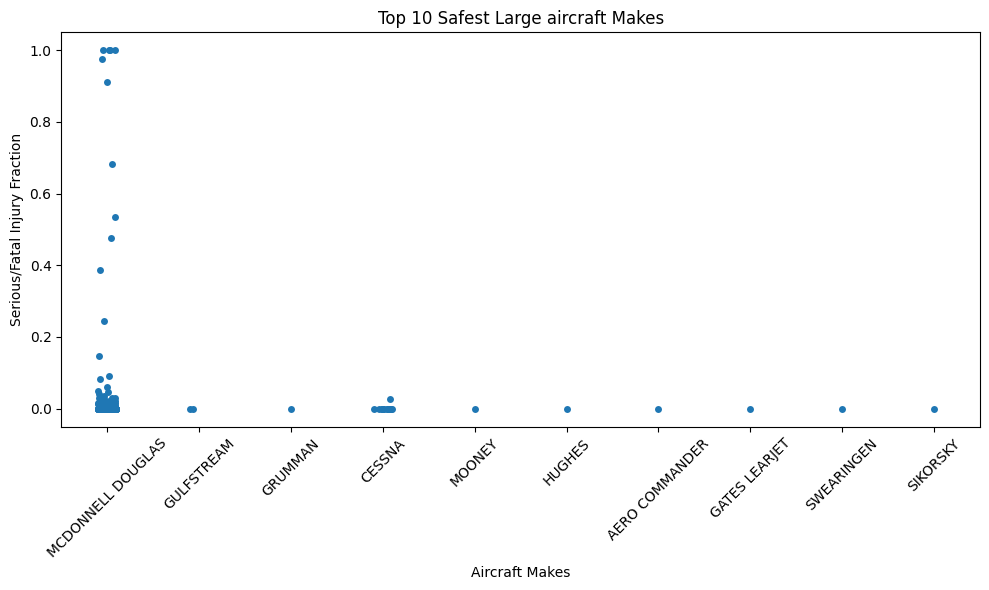

In [27]:
Large = df[df['Total.Passengers'] > 20]
mean_per_makeL = Large.groupby('Make')['Injury_fraction'].mean()

top_10_makes = mean_per_makeL.sort_values().head(10).index
large_top10 = Large[Large['Make'].isin(top_10_makes)]

plt.figure(figsize=(10,6))
sns.stripplot(data= large_top10, x= 'Make', y= 'Injury_fraction')
plt.title("Top 10 Safest Large aircraft Makes")
plt.xlabel("Aircraft Makes")
plt.ylabel("Serious/Fatal Injury Fraction")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [36]:
df['Aircraft.damage'] = df['Aircraft.damage'].str.upper().str.strip()
df['Aircraft.damage'] = df['Aircraft.damage'].replace({
    'DESTROYED': 'DESTROYED',
    'SUBSTANTIAL': 'NOT_DESTROYED',
    'MINOR': 'NOT_DESTROYED'
})

df['Destroyed'] = df['Aircraft.damage'] == 'DESTROYED'

In [38]:
#LETS CREATE A FUNCTION THAT WILL HELP SUM UP THE RATE OF AIRCRAFT DESTRUCTION

def aircraft_destruction(data):
    summary = data.groupby('Make').agg({
        'Destroyed': 'mean',
        'Make': 'count'
    }).rename(columns={'Make': 'Accident.Count'}).reset_index()
    
    return summary

small_make = aircraft_destruction(small)
large_make = aircraft_destruction(Large)
    
small_low15 = small_make.sort_values('Destroyed').head(15)
large_low15 = large_make.sort_values('Destroyed').head(15)

#Small Aircraft
plt.figure()
plt.barh(small_low15['Make'], small_low15['Destroyed'])
plt.title("Lowest Aircraft Destruction Rates")
plt.xlabel("Destruction Rates")
plt.show()

KeyError: "Label(s) ['Destroyed'] do not exist"

In [ ]:
#Large Aircraft
plt.figure()
plt.barh(large_low15['Make'], large_low15['Destroyed'])
plt.title("Lowest Aircraft Destruction Rates")
plt.xlabel("Destruction Rates")
plt.show()

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

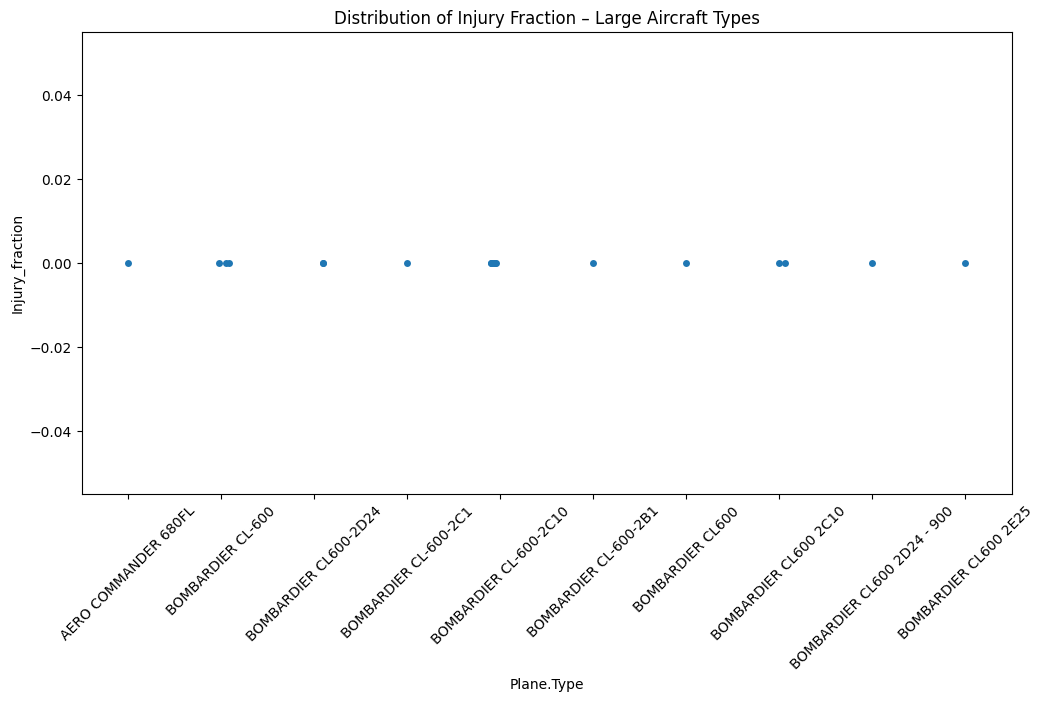

In [40]:
df['Plane.Type'] = df['Make'] + " " + df['Model']

small = df[df['Total.Passengers'] <= 20]
large = df[df['Total.Passengers'] > 20]
small_summary = small.groupby('Plane.Type')['Injury_fraction'].mean().sort_values().head(10)
large_summary = large.groupby('Plane.Type')['Injury_fraction'].mean().sort_values().head(10)


#Larger Planes 
top_large = large_summary.head(10).index

plt.figure(figsize=(12,6))

sns.stripplot(
    data=large[large['Plane.Type'].isin(top_large)],
    x='Plane.Type',
    y='Injury_fraction',
    jitter=True
)

plt.xticks(rotation=45)
plt.title("Distribution of Injury Fraction – Large Aircraft Types")
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

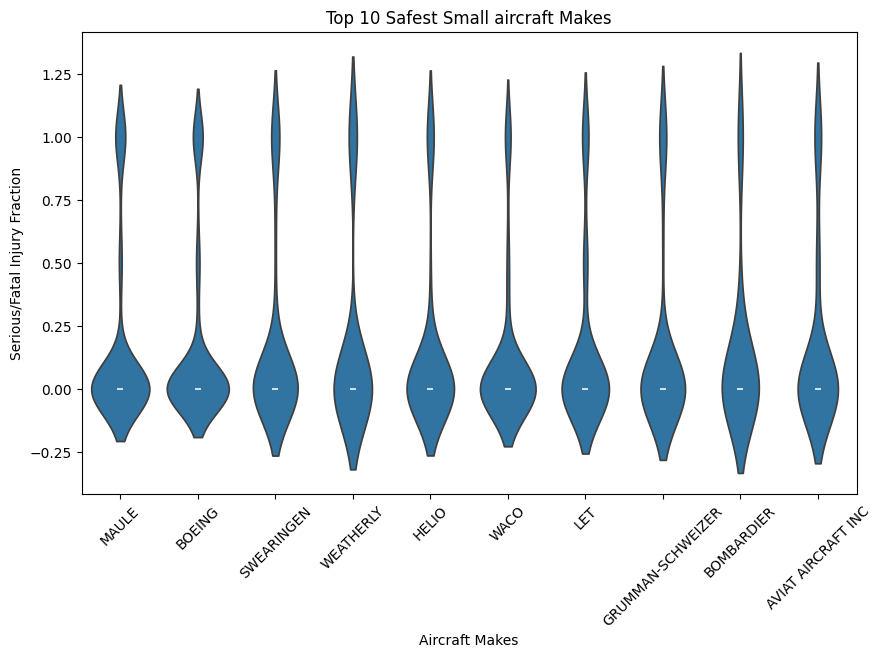

In [41]:
df = df.dropna(subset= ['Total.Passengers','Serious.Fatal'])
df = df[df['Total.Passengers'] > 0] # Passengers must be greater than 0 to be considered valid

df['Injury_fraction'] = df['Serious.Fatal']/df['Total.Passengers']

# Let's filter the small aircrafts
small = df[df['Total.Passengers'] <= 20]

#Mean injury Fraction per make
mean_per_make = small.groupby('Make')['Injury_fraction'].mean()


#Top 10 Safest Aircraft Makes
top_10_makes = mean_per_make.sort_values().head(10).index

small_top10 = small[small['Make'].isin(top_10_makes)]

plt.figure(figsize=(10,6))
sns.violinplot(data= small_top10, x= 'Make', y= 'Injury_fraction')
plt.title("Top 10 Safest Small aircraft Makes")
plt.xlabel("Aircraft Makes")
plt.ylabel("Serious/Fatal Injury Fraction")
plt.xticks(rotation = 45)
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

Small --> Small Aircraft models displayed higher mean fatal/serious injury fractions compared to large aircrafts. Hence, Small aircrafts are less consistent, and risk levels can vary significantly depending on the model and the operating conditions.

Large --> Large Aircrafts displayed low mean fatal/serious injury fractions, with many models showing near-zero injury rates across most recorded incidents, making them safer and more predictable, and making them highly favorable from a risk and insurance perspective.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

## 1) WEATHER CONDITION vs INJURY & DAMAGE

In [44]:

weather_summary = df.groupby('Weather.Condition').agg({
    'Injury_fraction': 'mean',
    'Destroyed': 'mean',
    'Weather.Condition': 'count'
}).rename(columns={'Weather.Condition':'Count'}).reset_index()

weather_summary

,Weather.Condition,Injury_fraction,Destroyed,Count
0,IMC,0.636562,0.572347,4665
1,UNKNOWN,0.591560,0.528736,870
2,VMC,0.225034,0.174845,53722


## 2) PHASE OF FLIGHT vs INJURY & DAMAGE

In [46]:
phase_summary = df.groupby('Broad.phase.of.flight').agg({
    'Injury_fraction': 'mean',
    'Destroyed': 'mean',
    'Broad.phase.of.flight': 'count'
}).rename(columns={'Broad.phase.of.flight':'Count'}).reset_index()

phase_summary = phase_summary[phase_summary['Count'] >= 50]
phase_summary = phase_summary.sort_values('Injury_fraction')

phase_summary

,Broad.phase.of.flight,Injury_fraction,Destroyed,Count
10,TAXI,0.021931,0.032509,1415
5,LANDING,0.041240,0.053848,10864
8,STANDING,0.150877,0.119938,642
9,TAKEOFF,0.222020,0.233209,8576
4,GO-AROUND,0.293845,0.308543,995
3,DESCENT,0.310405,0.301107,1355
0,APPROACH,0.326784,0.301534,4497
2,CRUISE,0.345018,0.355667,7403
1,CLIMB,0.387224,0.397507,1444
7,OTHER,0.396323,0.346667,75
